In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('data.csv')

print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [10]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Проверяем формат столбцов

In [11]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [12]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Сгруппируйте данные по дате, посчитайте количество продаж

In [13]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

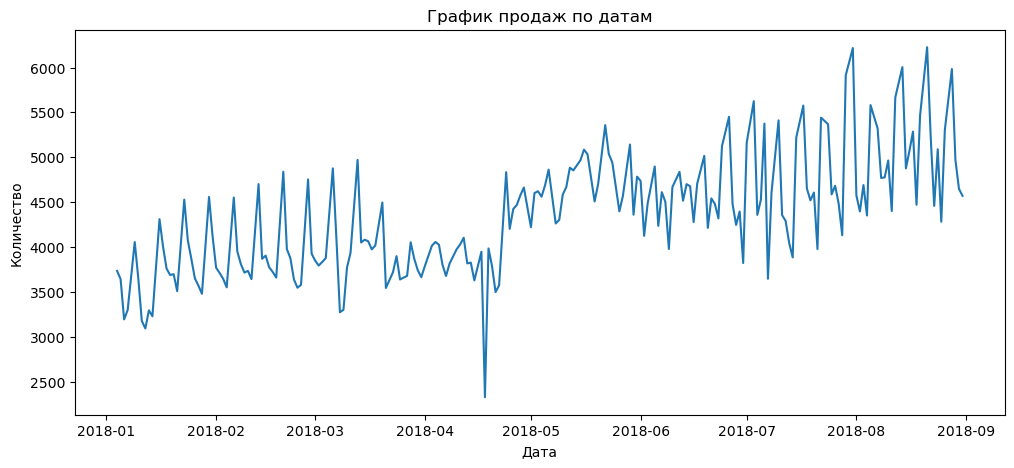

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('График продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество')

plt.show()

Нарисуйте график продаж у `grouped_df`

На графике отображена динамика продаж по датам с 2018 года. , Ось Х - Даты, ось У - суммарное количество проданных единиц в день, можно наблюдать за
резкими спадами и подьемами продаж

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [15]:
outlier_row = df[df['Количество'] == df['Количество'].max()]
print(outlier_row)

             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [16]:
filtered = df[(df['Склад'] == 3) &
    (df['Дата'].dt.dayofweek == 2) &
    (df['Дата'].dt.month.isin([6, 7, 8]))]

top_product = filtered.groupby('Номенклатура')['Количество'].sum().idxmax()
print("Топовый товар:", top_product)

Топовый товар: product_1


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [22]:
print(weather_raw.columns.tolist())

['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']


In [23]:
print(weather['Дата'].head(10).tolist())
print(weather['Дата'].dtype)

[Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2020-12-30 00:00:00'), Timestamp('2020-12-30 00:00:00')]
datetime64[ns]


In [24]:
weather_raw = pd.read_csv('weather.csv', 
                           sep=';', 
                           skiprows=6,
                           encoding='utf-8',
                           quotechar='"',
                           index_col=False)  

weather = weather_raw[['Местное время в Астане', 'T']].copy()
weather.columns = ['Дата', 'T']

weather['Дата'] = weather['Дата'].astype(str).str[:10]
weather['Дата'] = pd.to_datetime(weather['Дата'], format='%d.%m.%Y')
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

weather_daily = weather.groupby('Дата')['T'].mean().reset_index()
print(weather_daily.head(3))

        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625


In [25]:
# Объединяем
merged = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')
print(merged.head())
print('Строк:', len(merged))

        Дата  Количество        T
0 2018-01-04        3734 -14.0750
1 2018-01-05        3643 -16.8625
2 2018-01-06        3193 -13.3000
3 2018-01-07        3298 -12.7500
4 2018-01-09        4055  -6.2500
Строк: 205


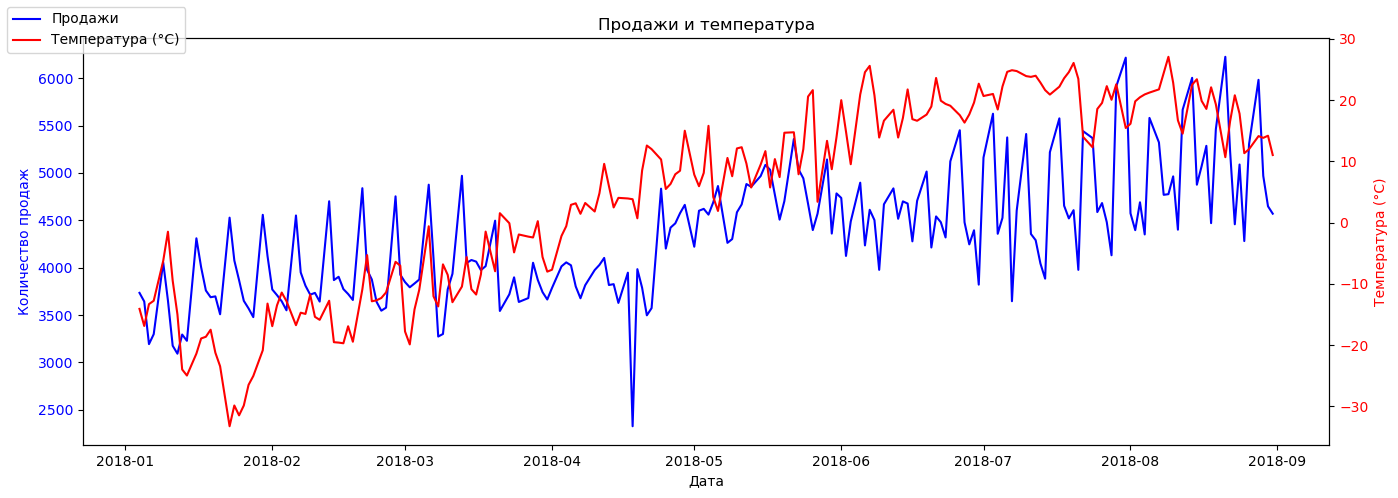

In [37]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Левая ось - продажи
ax1.plot(merged['Дата'], merged['Количество'], label='Продажи', color='blue')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Правая ось - температура
ax2 = ax1.twinx()  # создаём вторую ось Y
ax2.plot(merged['Дата'], merged['T'], label='Температура (C)', color='red')
ax2.set_ylabel('Температура (C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Продажи и температура')
fig.legend(loc='upper left')
plt.tight_layout()
plt.show()

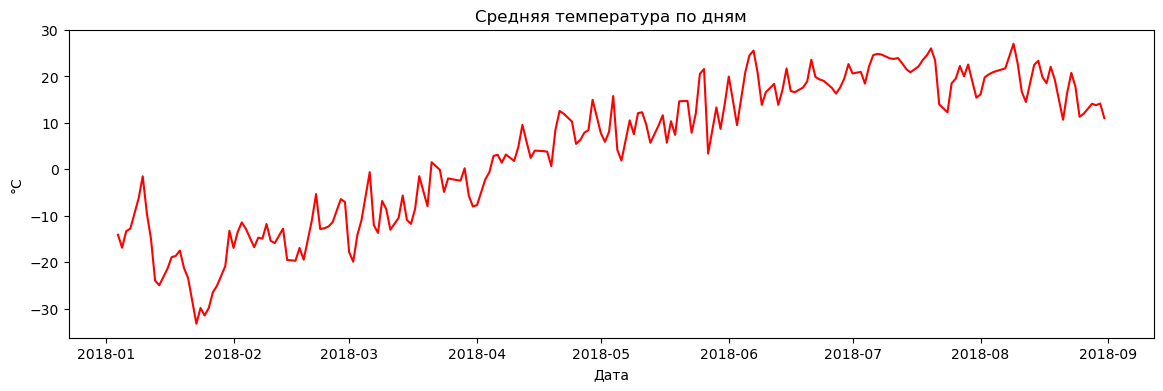

In [27]:
# Отдельный график температуры
plt.figure(figsize=(14, 4))
plt.plot(merged['Дата'], merged['T'], color='red')
plt.title('Средняя температура по дням')
plt.xlabel('Дата')
plt.ylabel('C')
plt.show()